# Data Visualization of Banned Books

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string
import re

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# the 'magic' or the percent symbol means it'll look good visually

In [42]:
data = pd.read_csv("openlibrary_subjects_match.csv")
data.head()

,clean_title,clean_author,subjects,source
0,...And Their Memory Was A Bitter Tree,Robert Howard,"['Fiction, fantasy, short stories']",openlibrary.org
1,(Non)Conform Russian And Soviet Art 1958-1995,Barbara Thiemann,[],openlibrary.org
2,Scuse Me While I Kiss The Sky,David Henderson,[],openlibrary.org
3,A Black Gaze,Tina Campt,[],openlibrary.org
4,A Black Rose Thrived,Rochelle Richey,[],openlibrary.org


In [43]:
data = data[data.subjects != "[]"] # drop all rows without subjects

In [44]:
data.head()

,clean_title,clean_author,subjects,source
0,...And Their Memory Was A Bitter Tree,Robert Howard,"['Fiction, fantasy, short stories']",openlibrary.org
5,A Brief History Of Album Covers,Jason Draper,"['Sound recordings', 'Packaging']",openlibrary.org
7,A Brief History Of Vice,Robert Evans,"['Vice', 'Modern Civilization', 'History', 'Ci...",openlibrary.org
9,A Centaur'S Life 10,Kei Murayama,"['Centaurs', 'Comic books, strips', 'High scho...",openlibrary.org
14,A Centaur'S Life 2,Kei Murayama,"['Juvenile fiction', 'Graphic novels', 'High s...",openlibrary.org


In [45]:
data.shape

(3775, 4)

In [46]:
banned_books = pd.read_csv("data/banned_book_data_tx-list.csv")
banned_books.head()

,publication,author,date,unit_deny_reason,reason,"note_on_sourcing:_i_got_this_information_through_a_request_to_the_tdcj_public_information_office,_received_10/14/2022.",year,month,day,state_arc
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,NaN,2016,8,19,tx
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,NaN,2012,9,10,tx
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,NaN,2019,7,17,tx
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,NaN,2010,1,29,tx
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",NaN,2021,9,8,tx


In [47]:
# clean up column names
banned_books = banned_books.rename(columns={
    "publication": "publication",
    "author": "author",
    "date": "date",
    "unit_deny_reason": "unit_reason",
    "reason": "reason",
    "year": "year",
    "month": "month",
    "day": "day",
    "state_arc": "state"
})

banned_books = banned_books.drop(columns=["note_on_sourcing:_i_got_this_information_through_a_request_to_the_tdcj_public_information_office,_received_10/14/2022."], errors="ignore")
banned_books.head()

,publication,author,date,unit_reason,reason,year,month,day,state
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,2016,8,19,tx
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,2012,9,10,tx
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,2019,7,17,tx
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,2010,1,29,tx
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",2021,9,8,tx


In [97]:
# clean the data
## step 1: convert to lowercase
banned_books["clean_reason"] = (
    banned_books["reason"]
    .str.lower()
    .str.strip()
)

banned_books["clean_reason"].head()

0                 pgs 81 & 369 sexually explicit image
1                                    pg 422 nude child
2                       pg 294 sexually explicit image
3    page 9 of photo insert contains sexually expli...
4    pages 28, 30 & 35 contain sexually explicit im...
Name: clean_reason, dtype: object

In [49]:
# clean the data
## step 2: remove punctuation
banned_books["clean_reason"] = (
    banned_books["clean_reason"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

banned_books["clean_reason"].head()

0                  pgs 81  369 sexually explicit image
1                                    pg 422 nude child
2                       pg 294 sexually explicit image
3    page 9 of photo insert contains sexually expli...
4     pages 28 30  35 contain sexually explicit images
Name: clean_reason, dtype: object

In [50]:
# clean the data
## step 3: remove 'pgs' and numbers
banned_books["clean_reason"] = (
    banned_books["clean_reason"]
    .str.replace(r"\bpgs\b", "", regex = True) # remove pgs
    .str.replace(r"\bpg\b", "", regex = True) # remove pg
    .str.replace(r"\bpage\b", "", regex = True) # remove page
    .str.replace(r"\bpages\b", "", regex = True) # remove pages
    .str.replace(r"\d+", "", regex = True) # remove numbers
    .str.strip()
)

banned_books["clean_reason"].head(100)

0                               sexually explicit image
1                                            nude child
2                               sexually explicit image
3     of photo insert contains sexually explicit images
4                      contain sexually explicit images
                            ...                        
95                                     sex with a minor
96                                incest brotherbrother
97                                                 rape
98                                                 rape
99                                                 rape
Name: clean_reason, Length: 100, dtype: object

In [51]:
# clean the data: title format
# lets define a function 'clean_title'
def clean_title(title):
    if pd.isna(title):
        return None

    title = str(title).strip()

    # re.sub(pattern, repl, string, count=0, flags=0)
    # return the string obtained by replacing the left-most non-overlapping
        # occurences of pattern in string by the replacement repl
            # r = raw string
            # , = ,
            # $ = if at the end of the string
        # en gros: replace trailing commas with nothing
    title = re.sub(r',$', '', title)

    # collapse spaces (solves problem of accidental double spacing)
    # \s = any whitespace character i.e. " " "\t" "\n"
    # + = one or more in a row
    title = re.sub(r'\s+', ' ', title)

    return title

In [52]:
# clean the data: author format
# let's define a function 'author_first_last'
# the .strip() function removes leading and trailing spaces/characters
    #(depending on the argument) to return a copy of the original string

def author_first_last(author):
    
    if pd.isna(author):
        return None

    author = author.strip() # default is spaces

    if "," in author:
        last, first = author.split(",", 1) # using , as the delimiter
        return f"{first.strip()} {last.strip()}" # recombine first & last name

    return author

In [53]:
banned_books["clean_author"] = (
    banned_books["author"]
    .apply(author_first_last)
    .str.title()
)

In [54]:
# banned_books.head()

In [55]:
banned_books["clean_title"] = (
    banned_books["publication"]
    .apply(clean_title)
    .str.title()
)

In [56]:
banned_books.head()

,publication,author,date,unit_reason,reason,year,month,day,state,clean_reason,clean_author,clean_title
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,2016,8,19,tx,sexually explicit image,Robert Howard,...And Their Memory Was A Bitter Tree
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,2012,9,10,tx,nude child,Barbara Thiemann,(Non)Conform Russian And Soviet Art 1958-1995
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,2019,7,17,tx,sexually explicit image,David Henderson,Scuse Me While I Kiss The Sky
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,2010,1,29,tx,of photo insert contains sexually explicit images,David Henderson,Scuse Me While I Kiss The Sky
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",2021,9,8,tx,contain sexually explicit images,Tina Campt,A Black Gaze


In [57]:
merged = pd.merge(
    banned_books,
    data[["subjects", "source", "clean_author", "clean_title"]],
    on=["clean_author","clean_title"],
    how="left"
)

merged.head()

,publication,author,date,unit_reason,reason,year,month,day,state,clean_reason,clean_author,clean_title,subjects,source
0,...AND THEIR MEMORY WAS A BITTER TREE,"HOWARD, ROBERT",2016-08-19,PAGES 81 & 369 SEXUALLY EXPLICIT IMAGE,PGS 81 & 369 SEXUALLY EXPLICIT IMAGE,2016,8,19,tx,sexually explicit image,Robert Howard,...And Their Memory Was A Bitter Tree,"['Fiction, fantasy, short stories']",openlibrary.org
1,"(NON)CONFORM RUSSIAN AND SOVIET ART 1958-1995,","THIEMANN, BARBARA",2012-09-10,PAGE 422 PHOTO OF A NUDE CHILD,PG 422 NUDE CHILD,2012,9,10,tx,nude child,Barbara Thiemann,(Non)Conform Russian And Soviet Art 1958-1995,NaN,NaN
2,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2019-07-17,PG 294 SEXUALLY EXPLICIT IMAGE,PG 294 SEXUALLY EXPLICIT IMAGE,2019,7,17,tx,sexually explicit image,David Henderson,Scuse Me While I Kiss The Sky,NaN,NaN
3,SCUSE ME WHILE I KISS THE SKY,"HENDERSON, DAVID",2010-01-29,PAGE 310 CONTAINS SEXUALLY EXPLICIT IMAGES,PAGE 9 OF PHOTO INSERT CONTAINS SEXUALLY EXPLI...,2010,1,29,tx,of photo insert contains sexually explicit images,David Henderson,Scuse Me While I Kiss The Sky,NaN,NaN
4,A BLACK GAZE,"CAMPT, TINA",2021-09-08,"PAGES 28, 30, 35 SEXUALLY EXPLICIT IMAGES","PAGES 28, 30 & 35 CONTAIN SEXUALLY EXPLICIT IM...",2021,9,8,tx,contain sexually explicit images,Tina Campt,A Black Gaze,NaN,NaN


In [58]:
merged = merged.drop(columns=["publication","author","unit_reason","reason","month","day"], errors="ignore")
merged.head()

,date,year,state,clean_reason,clean_author,clean_title,subjects,source
0,2016-08-19,2016,tx,sexually explicit image,Robert Howard,...And Their Memory Was A Bitter Tree,"['Fiction, fantasy, short stories']",openlibrary.org
1,2012-09-10,2012,tx,nude child,Barbara Thiemann,(Non)Conform Russian And Soviet Art 1958-1995,NaN,NaN
2,2019-07-17,2019,tx,sexually explicit image,David Henderson,Scuse Me While I Kiss The Sky,NaN,NaN
3,2010-01-29,2010,tx,of photo insert contains sexually explicit images,David Henderson,Scuse Me While I Kiss The Sky,NaN,NaN
4,2021-09-08,2021,tx,contain sexually explicit images,Tina Campt,A Black Gaze,NaN,NaN


In [59]:
merged = merged[merged["subjects"].notna()] # drop all rows without subjects

In [60]:
merged.head()

,date,year,state,clean_reason,clean_author,clean_title,subjects,source
0,2016-08-19,2016,tx,sexually explicit image,Robert Howard,...And Their Memory Was A Bitter Tree,"['Fiction, fantasy, short stories']",openlibrary.org
6,2020-12-31,2020,tx,nude child,Jason Draper,A Brief History Of Album Covers,"['Sound recordings', 'Packaging']",openlibrary.org
8,2016-09-23,2016,tx,contains a sexually explicit image,Robert Evans,A Brief History Of Vice,"['Vice', 'Modern Civilization', 'History', 'Ci...",openlibrary.org
10,2018-06-25,2018,tx,sexually explicit images,Kei Murayama,A Centaur'S Life 10,"['Centaurs', 'Comic books, strips', 'High scho...",openlibrary.org
15,2018-09-11,2018,tx,sexually explicit image,Kei Murayama,A Centaur'S Life 2,"['Juvenile fiction', 'Graphic novels', 'High s...",openlibrary.org


In [61]:
merged.shape

(3878, 8)

In [62]:
reason_counts = merged['clean_reason'].value_counts()

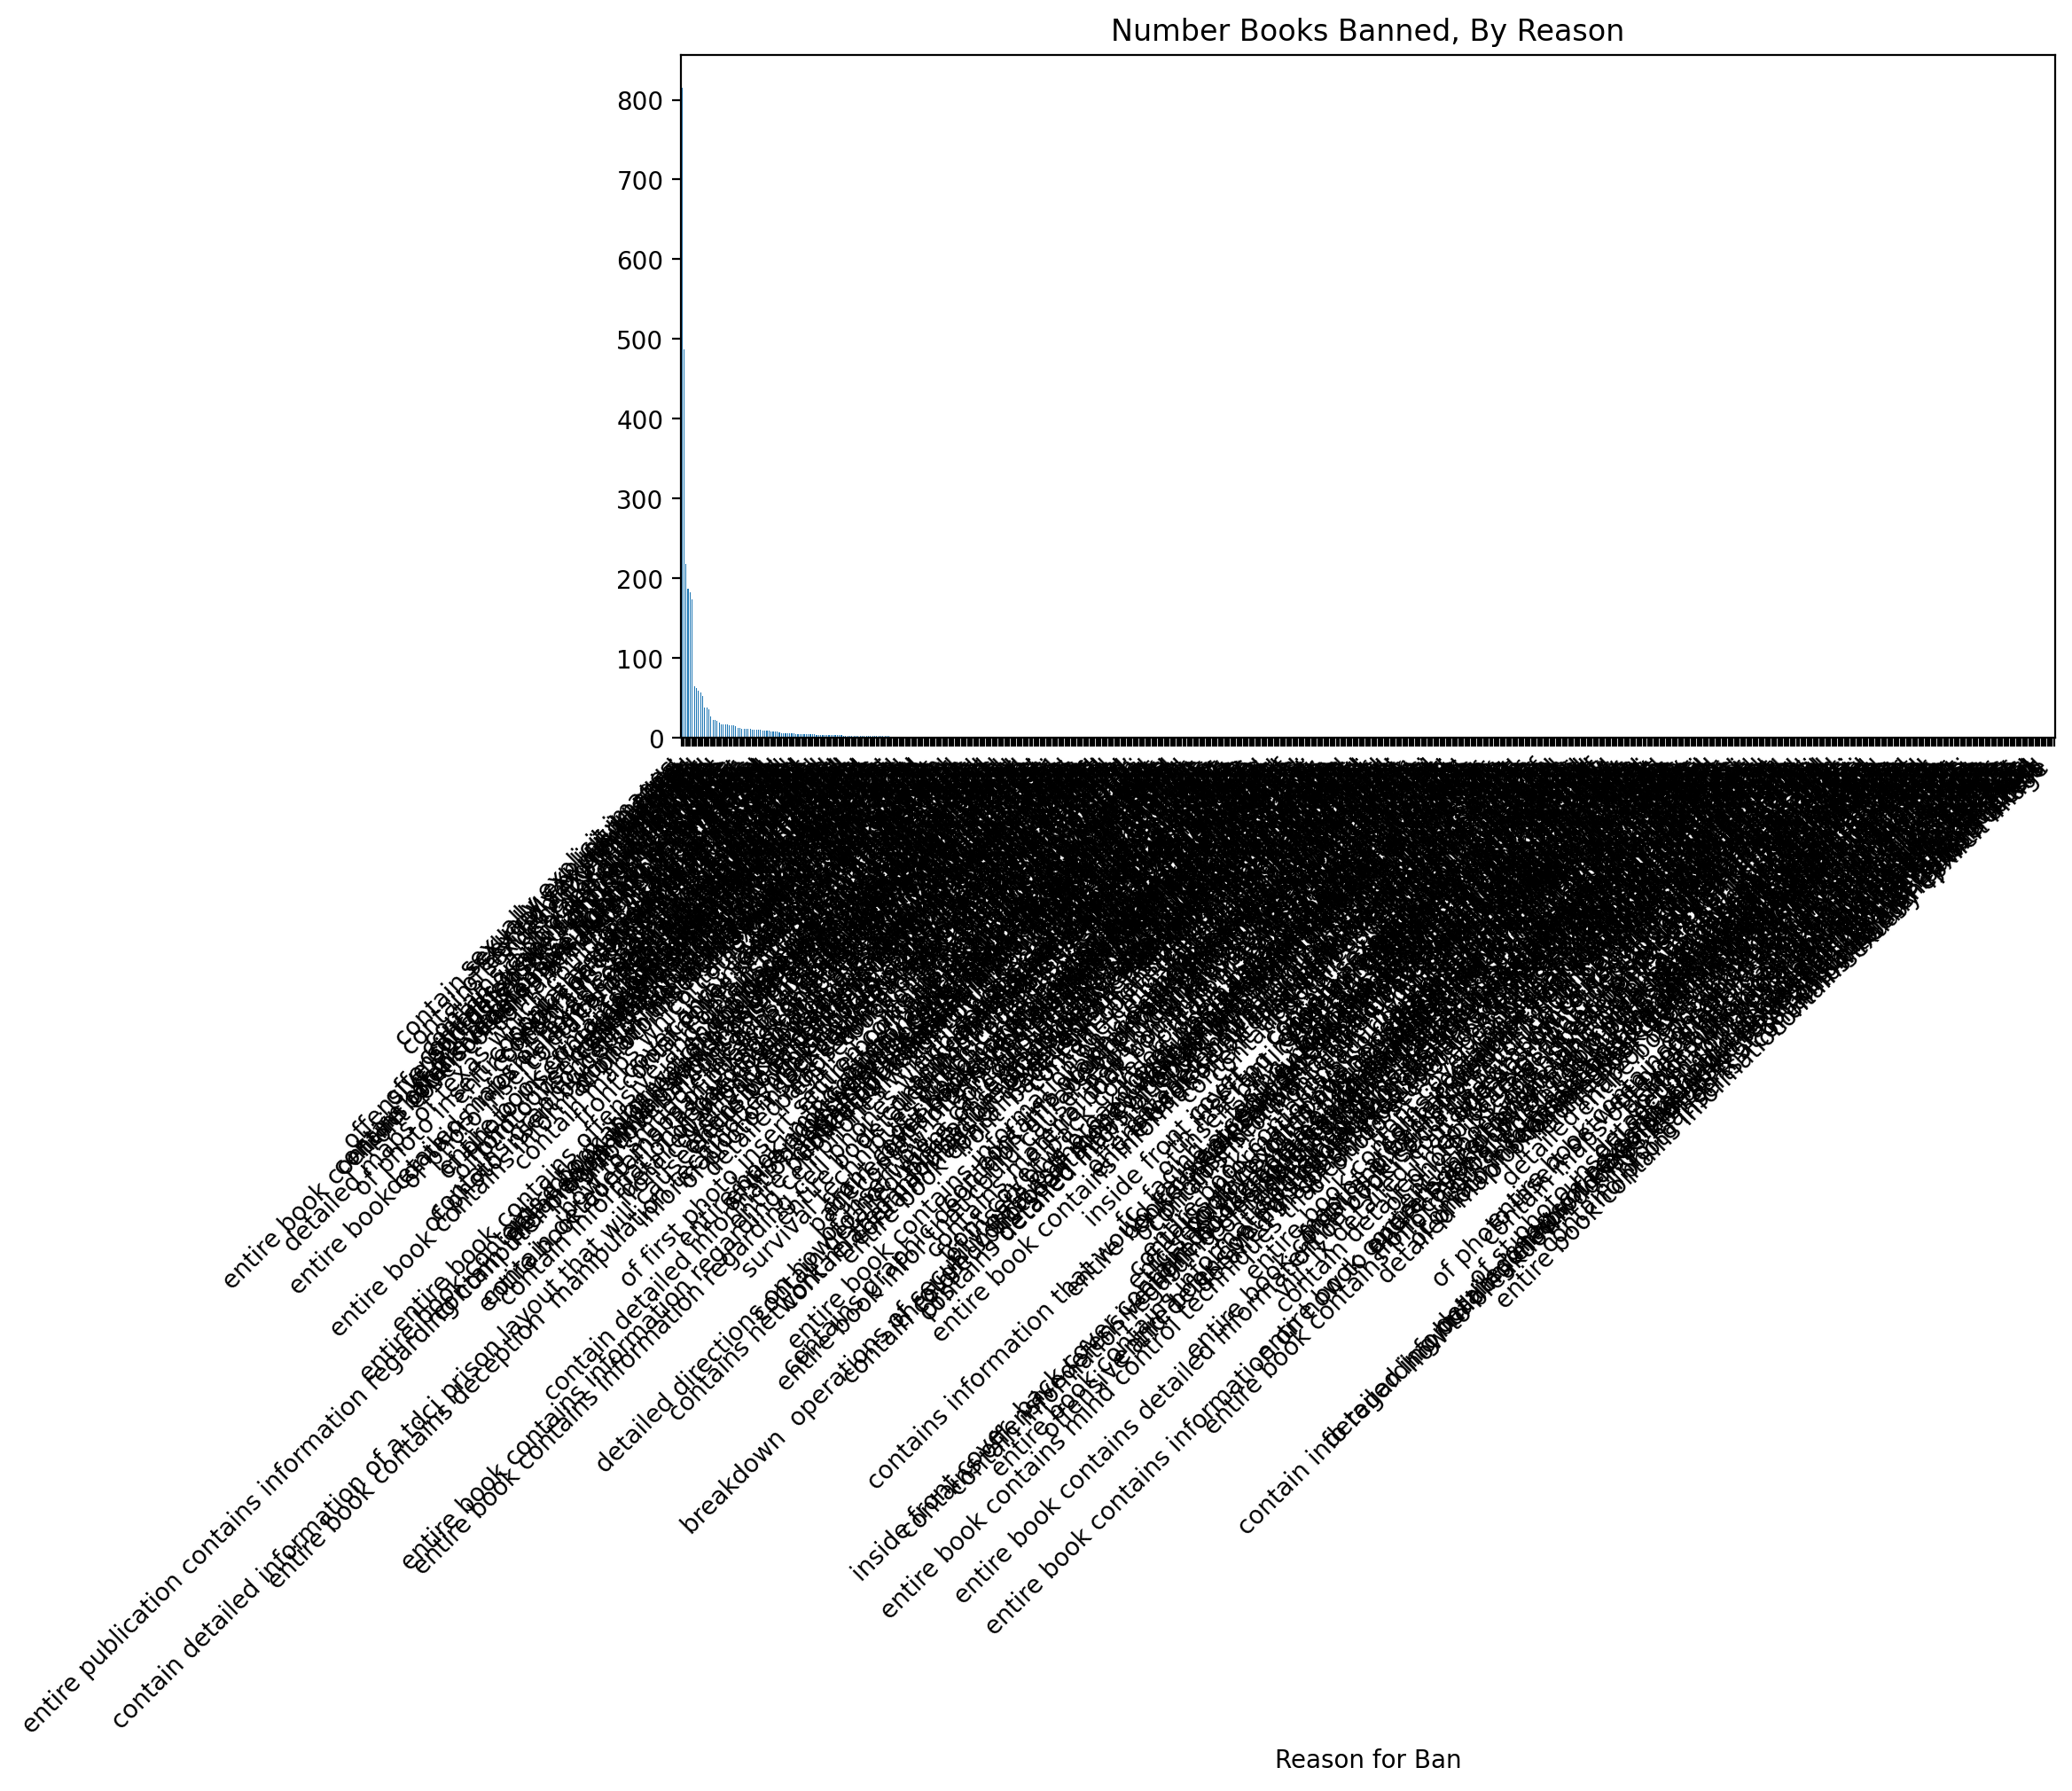

In [63]:
# question: what is the most common reason for book bans in texas state prisons?
reason_counts.plot.bar(figsize=(10, 5), legend=False)
# figsize=(vertical, horizontal)
plt.xlabel("Reason for Ban")
plt.title("Number Books Banned, By Reason")
plt.xticks(rotation=45, ha="right");

In [64]:
# get rid of stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)
# import english stop words and make them a set called stopwords

In [65]:
merged["clean_reason"] = merged["clean_reason"].astype(str)

merged["clean_reason"] = merged["clean_reason"].apply( # have column
    lambda x: " ".join( # use x as a variable in a row in that column
        word for word in x.split()
        if word not in stopwords # compares all words in stopwords list to this list,
    )
)

merged["clean_reason"].head()

# column.apply(lambda x: function(x)) allows you to make a more complicated function
# lambda indicates that the thing after it is a variable

0              sexually explicit image
6                           nude child
8     contains sexually explicit image
10            sexually explicit images
15             sexually explicit image
Name: clean_reason, dtype: object

In [66]:
all_words = " ".join(
    merged["clean_reason"].astype(str)
).lower().split()

Counter(all_words).most_common(15)

[('sexually', 1400),
 ('explicit', 1385),
 ('images', 1175),
 ('rape', 682),
 ('contain', 402),
 ('child', 370),
 ('contains', 312),
 ('nude', 278),
 ('image', 252),
 ('sex', 205),
 ('sei', 205),
 ('age', 189),
 ('techniques', 177),
 ('fighting', 155),
 ('wminor', 151)]

In [67]:
# all_words is from the reason column
from nltk import ngrams

bigrams = list(
    ngrams(all_words, 2)
)

Counter(bigrams).most_common(25)

[(('sexually', 'explicit'), 1380),
 (('explicit', 'images'), 1153),
 (('images', 'sexually'), 379),
 (('nude', 'child'), 266),
 (('contain', 'sexually'), 243),
 (('explicit', 'image'), 228),
 (('rape', 'rape'), 165),
 (('fighting', 'techniques'), 148),
 (('sex', 'wminor'), 148),
 (('images', 'rape'), 130),
 (('images', 'contain'), 124),
 (('rape', 'sexually'), 119),
 (('contains', 'sexually'), 107),
 (('entire', 'book'), 106),
 (('offdef', 'fighting'), 86),
 (('ind', 'wchild'), 85),
 (('image', 'sexually'), 83),
 (('wminor', 'age'), 75),
 (('indecency', 'child'), 72),
 (('sei', 'sexually'), 71),
 (('book', 'contains'), 69),
 (('rape', 'minor'), 67),
 (('child', 'sexually'), 66),
 (('images', 'nude'), 63),
 (('images', 'contains'), 62)]

In [86]:
# sum common reasons
## sexually explicit images or sei
# rewrite this whole portion recursively or smth, maybe w a key

merged["clean_reason"].str.contains(
    r"sei|sexually explicit images|sexually explicit image",
    case=False,
    na=False
).sum()

np.int64(1581)

In [87]:
# rape
filtered = merged.copy()


filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image",
        case=False,
        na=False
    )
]


filtered["clean_reason"].str.contains(
   "rape",
   case=False,
   na=False
).sum()

np.int64(675)

In [88]:
# sex w minor
filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image|rape",
        case=False,
        na=False
    )
]

filtered["clean_reason"].str.contains(
   r"sex wminor|sex minor",
   case=False,
   na=False
).sum()

np.int64(177)

In [89]:
filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image|rape|sex wminor|sex minor",
        case=False,
        na=False
    )
]

## ind wchild or indecency child
filtered["clean_reason"].str.contains(
    r"ind wchild|indecency child",
    case=False,
    na=False
).sum()

np.int64(148)

In [81]:
## incest
filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image|rape|sex wminor|sex minor|ind wchild|indecency child",
        case=False,
        na=False
    )
]

filtered["clean_reason"].str.contains("incest", case=False, na=False).sum()

np.int64(92)

In [82]:
# escape
filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image|rape|sex wminor|sex minor|ind wchild|indecency child|incest",
        case=False,
        na=False
    )
]

filtered["clean_reason"].str.contains("escape", case=False, na=False).sum()

np.int64(64)

In [83]:
# security
filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image|rape|sex wminor|sex minor|ind wchild|indecency child|incest|escape",
        case=False,
        na=False
    )
]

filtered["clean_reason"].str.contains("security", case=False, na=False).sum()

np.int64(49)

In [95]:
# misc
filtered = filtered.loc[
    ~filtered["clean_reason"].str.contains(
        r"sei|sexually explicit images|sexually explicit image|rape|sex wminor|sex minor|ind wchild|indecency child|incest|escape|security",
        case=False,
        na=False
    )
]

filtered["clean_reason"].str.contains("nude child", case=False, na=False).sum()

np.int64(273)

In [93]:
filtered.head(10)

,date,year,state,clean_reason,clean_author,clean_title,subjects,source
6,2020-12-31,2020,tx,nude child,Jason Draper,A Brief History Of Album Covers,"['Sound recordings', 'Packaging']",openlibrary.org
18,2008-09-19,2008,tx,nude child,Lennart Nilsson,A Child Is Born,"['Pregnancy', 'Childbirth', 'Pictorialworks', ...",openlibrary.org
29,2013-03-04,2013,tx,brk wpn,Bruce Canfield,A Collector'S Guide To United States Combat,"['Shotguns', 'Assault weapons']",openlibrary.org
33,2020-01-15,2020,tx,insert bw contains manufacture explosives,William Reid,A Dark Night In Aurora,"['Mass murder', 'United states, social conditi...",openlibrary.org
34,2002-02-11,2002,tx,ftrdtr,Dena Kleiman,A Deadly Silence,"['Case studies', 'Incest', 'Murder', 'Parricid...",openlibrary.org
43,2015-10-27,2015,tx,mfg alc,Jon Hughes,A Druid'S Handbook To The Spiritual Power Of P...,"['Magic', 'Plants', 'Celtic Magic', 'Sex', 'BO...",openlibrary.org
68,2017-12-12,2017,tx,contain self defense techniques,Terry Schappert,A Guide To Improvised Weaponry,"['Self-defense', 'Handbooks, manuals', 'SPORTS...",openlibrary.org
69,2017-07-20,2017,tx,nude child,Barbara Bates,A Guide To Physical Examination And History Ta...,"['Textbooks', 'Physics textbooks', 'Medical ex...",openlibrary.org
70,2008-09-19,2008,tx,nude child,Nathan Constantine,A History Of Cannibalism,['Cannibalism'],openlibrary.org
71,2020-03-24,2020,tx,nude child,Nathan Constantine,A History Of Cannibalism,['Cannibalism'],openlibrary.org
